# 02 - Resultados del modelo clásico

Lectura auditable de la corrida final. El entrenamiento se ejecuta únicamente desde `python -m src.experiments.run`; aquí no se reabre el test para seleccionar modelos.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'results/latest_run.json').exists())
latest = json.loads((ROOT / 'results/latest_run.json').read_text(encoding='utf-8'))
RUN = ROOT / latest['path']
RUN

WindowsPath('C:/Users/Amerc/Documents/Quantathon2026/results/runs/final-gpu-20260802-lockbox')

In [2]:
classical = pd.read_csv(RUN / 'metrics/classical_summary.csv')
display(classical.sort_values('f1', ascending=False).round(4))

required = json.loads((RUN / 'metrics/classical_required.json').read_text(encoding='utf-8'))
optuna = json.loads((RUN / 'metrics/classical_optuna_nested.json').read_text(encoding='utf-8'))
safety = json.loads((RUN / 'metrics/classical_control_safety_threshold.json').read_text(encoding='utf-8'))
print('SVM requerida:', required['best_params'])
print('SVM Optuna:', optuna['best_params'])
print('Umbral de seguridad:', safety['threshold'], '| FPR no potable -> potable:', safety['false_positive_rate'])

,model,accuracy,balanced_accuracy,precision,recall,f1,specificity,false_positive_rate,mcc,roc_auc,average_precision
1,SVM requerida,0.6159,0.6168,0.5064,0.6211,0.5579,0.6125,0.3875,0.2281,0.6637,0.5527
2,SVM Optuna,0.6341,0.6184,0.5303,0.5469,0.5385,0.6900,0.3100,0.2356,0.6688,0.5498
3,Control: hist_gradient_boosting,0.6021,0.5781,0.4898,0.4688,0.4790,0.6875,0.3125,0.1576,0.6142,0.5186
0,Dummy,0.6098,0.5000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.3902


SVM requerida: {'C': 10.0, 'gamma': 'scale'}
SVM Optuna: {'C': 12.354692136503903, 'balance_strategy': 'undersample', 'scaler_strategy': 'robust', 'add_indicator': True, 'gamma': 'auto'}
Umbral de seguridad: 0.6167656922374044 | FPR no potable -> potable: 0.0975


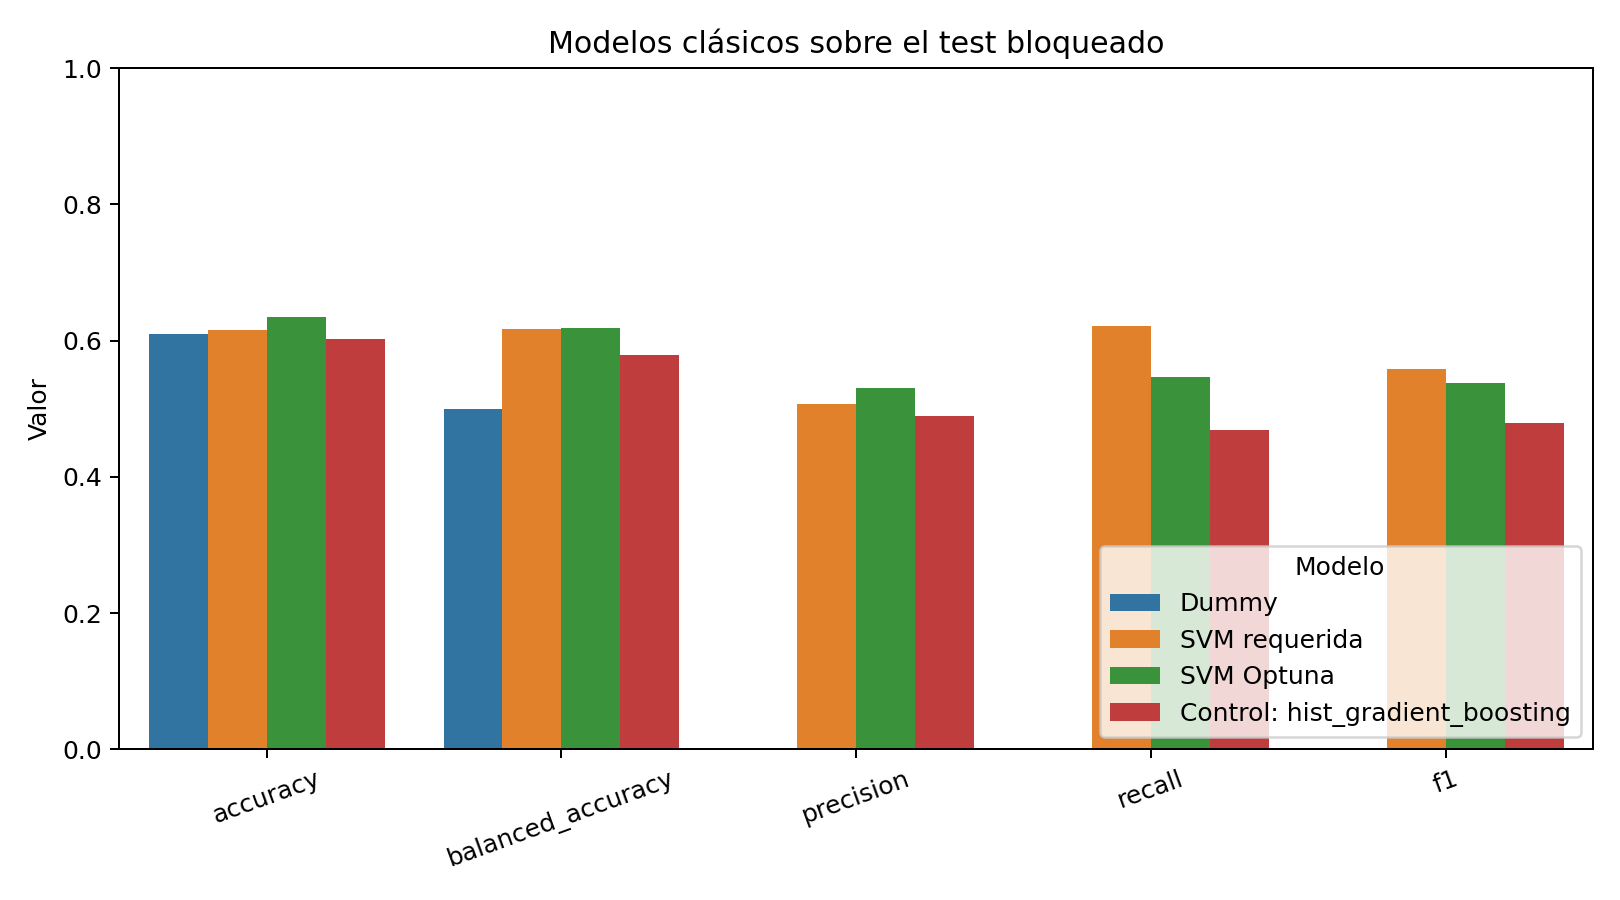

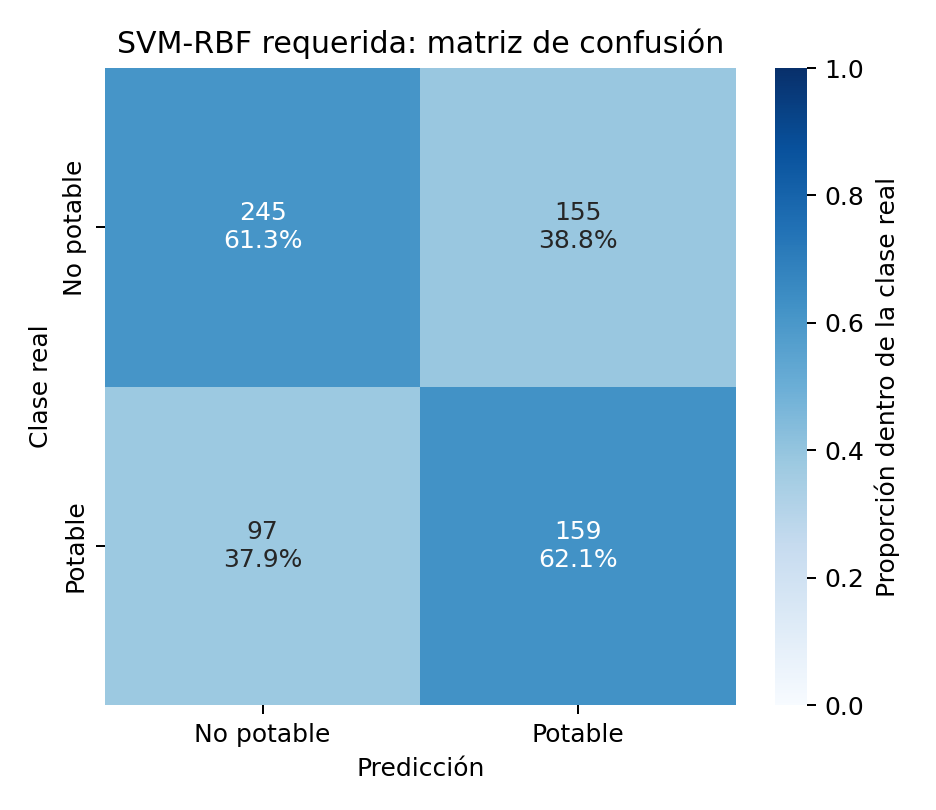

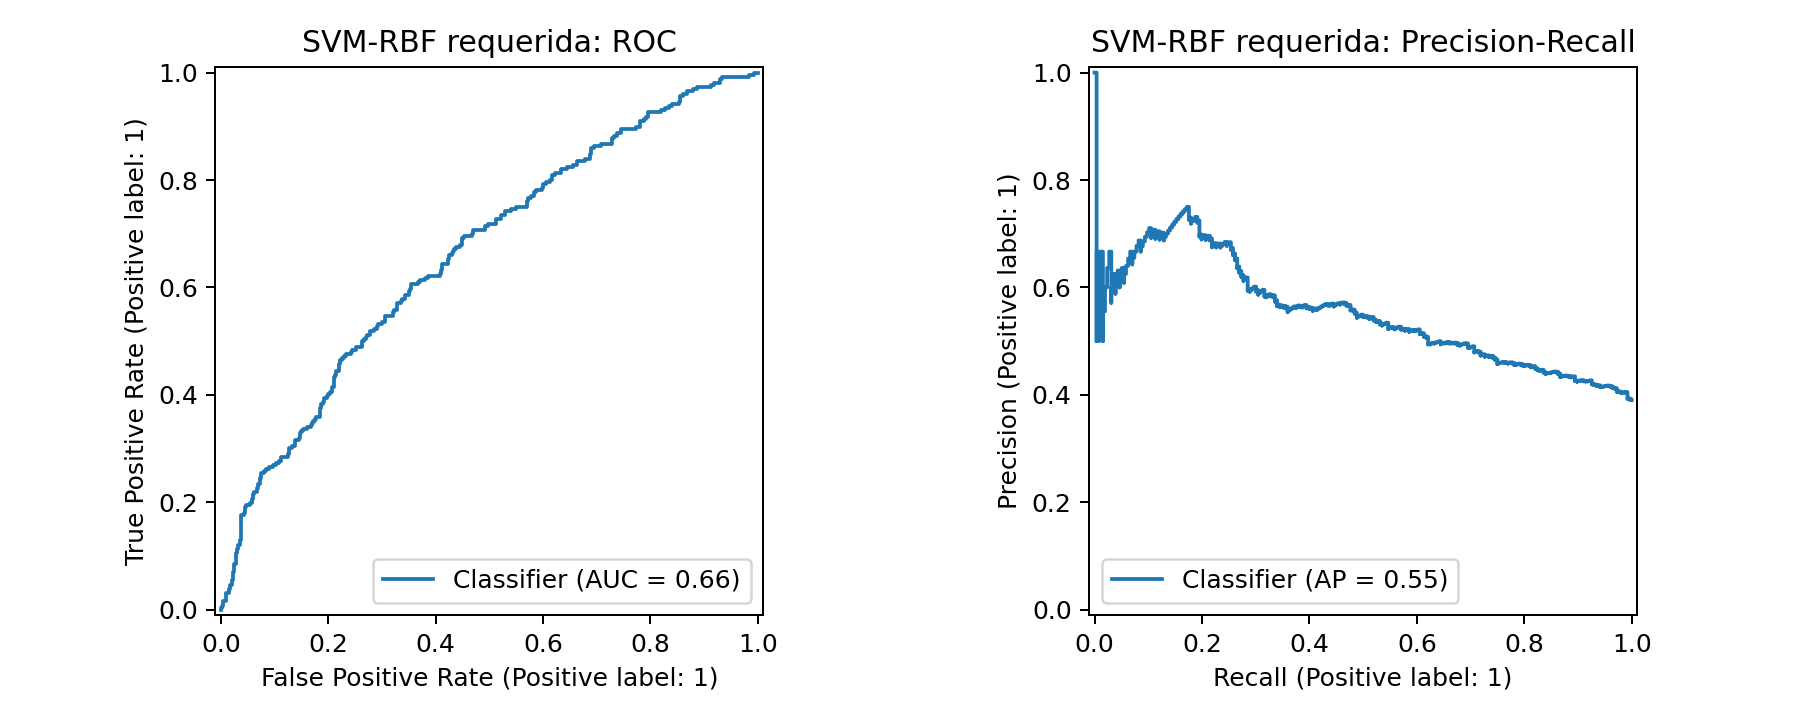

In [3]:
display(Image(filename=str(RUN / 'figures/classical_model_comparison.png'), width=950))
display(Image(filename=str(RUN / 'figures/classical_required_confusion.png'), width=560))
display(Image(filename=str(RUN / 'figures/classical_required_roc_pr.png'), width=900))

La SVM de la rúbrica obtiene F1 ≈ 0.558 y balanced accuracy ≈ 0.617. El umbral de seguridad se eligió solo con scores *out-of-fold* y reduce a menos de 10% el error crítico, a costa de una fuerte caída de sensibilidad.